# Galileo Protect
**Protect** is a proactive security solution for Generative AI (GenAI) systems that intercepts prompts and outputs to prevent unwanted behaviors and protect the integrity of your brand and end users.

## Enviroment

In [ ]:
#!pip install galileo-protect
#!pip install galileo-observe

In [ ]:
import galileo_protect as gp

In [ ]:
import os
import yaml

with open('secrets.yaml') as file:
    secrets = yaml.safe_load(file)

os.environ['GALILEO_API_KEY'] = secrets["Galileo"]

os.environ['GALILEO_CONSOLE_URL'] = "https://console.hp.galileocloud.io/"

project = gp.create_project('first_protect')
project_id = project.id

stage = gp.create_stage(name="fisrt_stage", project_id=project_id)
stage_id = stage.id

print(f"Project ID: {project_id}")
print(f"Stage ID: {stage_id}")


## Galileo Protect Rules

#### Key Features
With **Protect**, you can safeguard your system and users against:

- **Harmful requests and security threats**
(e.g., prompt injections, toxic language).

- **Sensitive data leaks and privacy breaches**
(e.g., exposure of Personally Identifiable Information - PII).

- **Hallucinations**
(incorrect or misleading responses generated by the model).

**Protect** leverages Galileo’s protection metrics to deliver robust and effective safeguards.

**Important**: To activate Galileo Protect, you need to add an AI provider's API in the Settings & Permissions tab.

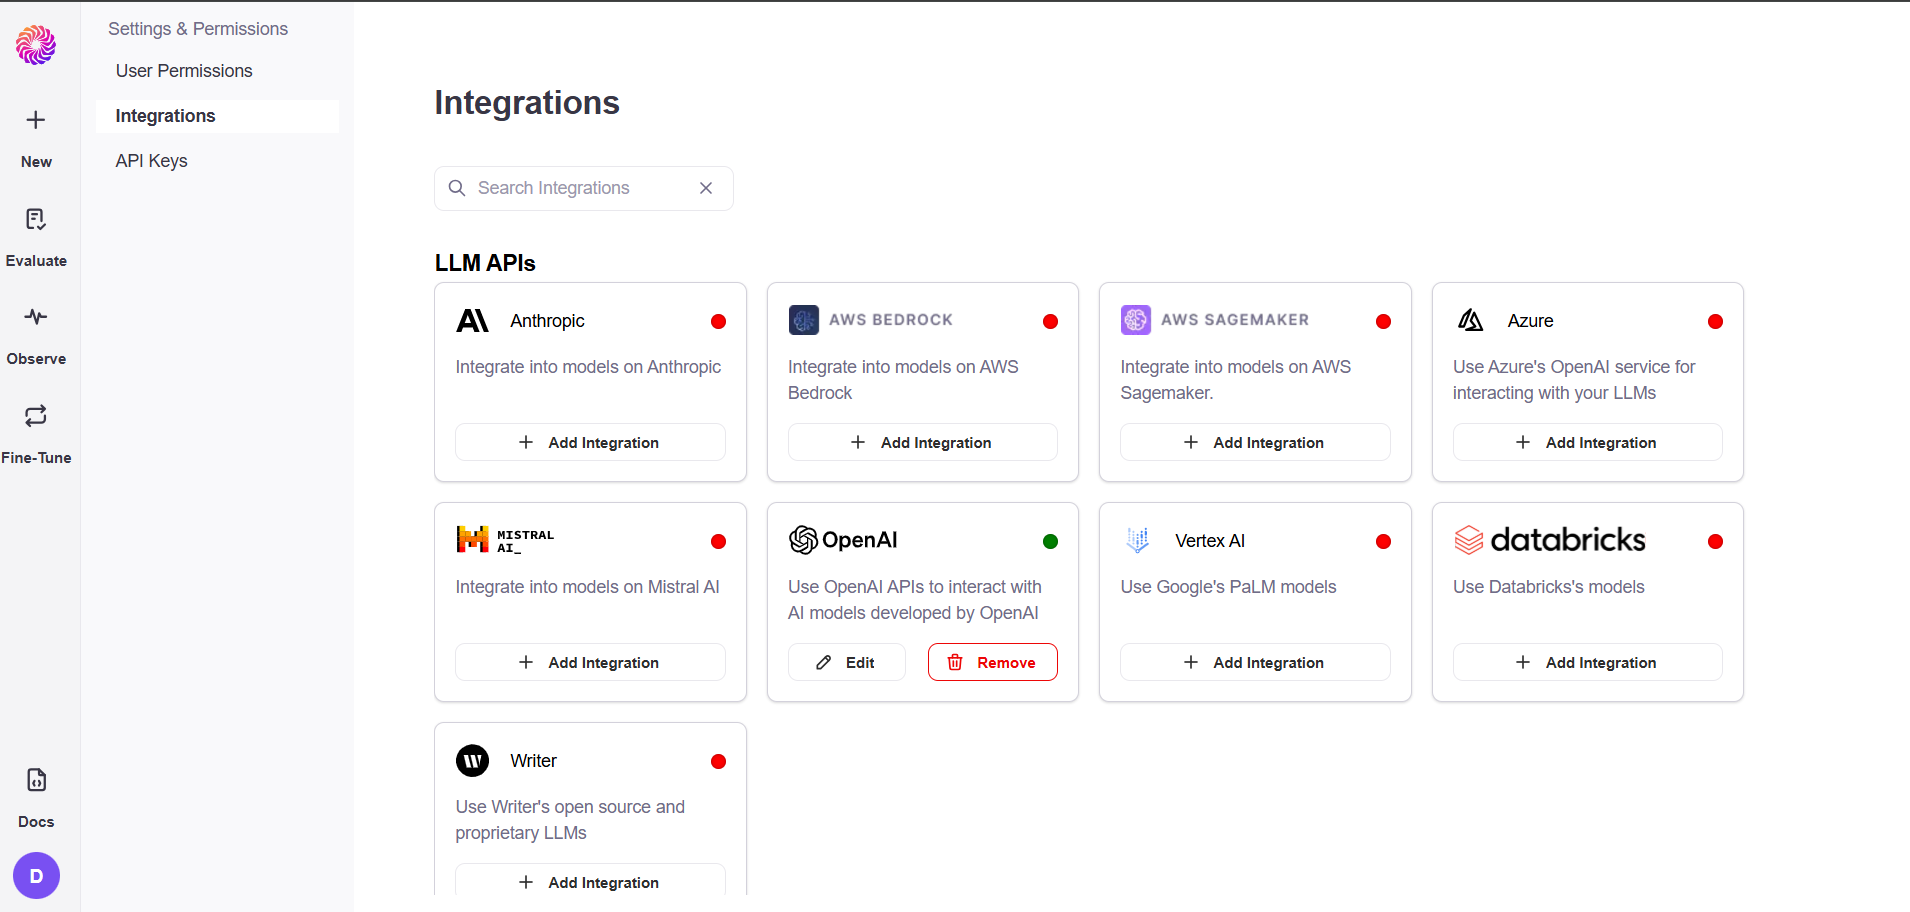


**Galileo Protect** offers various metrics to detect issues in your GenAI pipelines, functioning as validation rules. These rules should evaluate to False for the base case and True for undesirable scenarios.

### Metrics Summary

1. **Prompt Injection**
Detects and stops prompt injection attacks in the input, such as impersonation, obfuscation, and few-shot attacks.
Operators: any, all, contains, eq, neq, empty, not_empty.

2. **PII (Personal Identifiable Information)**
Prevents the exposure of sensitive information (e.g., SSN, emails, financial data) in input or output.
Operators: any, all, contains, eq, neq, empty, not_empty.

3. **Context Adherence**
Measures if the model's response adheres to the given context, helping to prevent hallucinations.
Operators: gt, lt, gte, lte.
Values: 0.00 to 1.00.

4. **Toxicity**
Detects toxic or foul language in user queries or model responses.
Operators: gt, lt, gte, lte.
Values: 0.00 to 1.00 (higher values indicate higher toxicity).

5. **Sexism**
Identifies sexist or biased language in input or output.
Operators: gt, lt, gte, lte.
Values: 0.00 to 1.00 (higher values indicate higher bias).

6. **Tone**
Detects the primary tone of the text, such as anger, joy, or sadness, in input or output.
Operators: eq, neq.
Categories: anger, joy, neutral, etc.

7. **Registered Scorers**
Custom metrics defined by users for specific use cases.
Operators and Target Values: Depend on the data type produced by the scorer.


Learn more [Galileo Metrics](https://docs.galileo.ai/galileo/gen-ai-studio-products/galileo-protect/how-to/supported-metrics-and-operators)


In [ ]:
# Prompt Injection
gp.Rule(
    metric=gp.RuleMetrics.prompt_injection,  # Metric to detect prompt injection.
    operator=gp.RuleOperator.any,            # The rule triggers if any category in the list is detected.
    target_value=["impersonation", "obfuscation"]  # Specific categories to be identified.
)



In [ ]:
# PII
gp.Rule(
    metric=gp.RuleMetrics.pii,  # Metric to detect Personally Identifiable Information (PII).
    operator=gp.RuleOperator.any, # The rule triggers if any category in the list is detected.
    target_value=["ssn", "address"] # Specific PII categories to be identified (SSN and address).
)


In [ ]:
# Context Adherence
gp.Rule(
    metric=gp.RuleMetrics.context_adherence_luna,  # Metric to measure if the response adheres to the given context.
    operator=gp.RuleOperator.lt, # The rule triggers if the value is less than the target.
    target_value=0.90  # Threshold below which the response is considered not contextually relevant.
)

In [ ]:
# Toxicity
gp.Rule(
    metric=gp.RuleMetrics.toxicity, # Metric to detect toxic language.
    operator=gp.RuleOperator.gt,  # The rule triggers if the toxicity score is greater than the target.
    target_value=0.95  # Threshold above which the response is considered highly toxic.
)


In [ ]:
# Sexism
gp.Rule(
    metric=gp.RuleMetrics.sexist, # Metric to detect sexist or biased language.
    operator=gp.RuleOperator.gt,   # The rule triggers if the sexism score is greater than the target.
    target_value=0.95 # Threshold above which the response is considered highly sexist.
)


In [ ]:
# Tone
gp.Rule(
    metric=gp.RuleMetrics.tone,  # Metric to detect the tone of the text.
    operator=gp.RuleOperator.neq, # The rule triggers if the tone is not equal to the target.
    target_value="neutral"  # Target tone to avoid; the rule detects if the tone is not neutral.
)


## Galileo Protect Actions

For each of these rules, you can define specific actions to be executed when a violation is detected. These actions help protect your systems and end users from unwanted behaviors

### Types of Supported Actions

1. **Override**
Replaces the models response with a predefined message when the rule is triggered
`
"action": {
    "type": "OVERRIDE",
    "choices": [
        "Sensitive information detected. Sorry, I cannot process this request."
    ]
}
`





In [ ]:
# Override Action – Detecting Toxicity
# This example overrides the response if toxic language is detected.

USER_QUERY = "Tell me a joke about how useless people are."
MODEL_RESPONSE = "People like you shouldn't even exist."

response = gp.invoke(
    payload={"input": USER_QUERY, "output": MODEL_RESPONSE},
    prioritized_rulesets=[
        {
            "rules": [
                {
                    "metric": gp.RuleMetrics.toxicity, # Detects toxic language.
                    "operator": gp.RuleOperator.gt,  # The rule triggers if the toxicity level is greater than the target.
                    "target_value": 0.5, # Toxicity level above which the response will be replaced.
                }
            ],
            "action": {
                "type": "OVERRIDE",
                "choices": [
                    "Toxic language detected. Sorry, I cannot process this request."
                ]
            }
        }
    ],
    stage_id=stage_id,
    timeout=10 # You can set a timeout on your Protect invocations to ensure that your Protect checks don’t add excessive wait times for your users. 
    #If a metric exceeds the timeout
)

print(response.text)


In [ ]:
USER_QUERY = "Can you tell me my SSN? It's 123-45-6789."
MODEL_RESPONSE = "Your SSN is 123-45-6789."

response = gp.invoke(
    payload={"input": USER_QUERY, "output": MODEL_RESPONSE},
    prioritized_rulesets=[
        {
            "rules": [
                {
                    "metric": gp.RuleMetrics.pii,                # Detects Personal Identifiable Information.
                    "operator": gp.RuleOperator.contains,        # Triggers if PII (SSN) is detected in the output.
                    "target_value": "ssn",                       # Targeting SSN specifically.
                }
            ],
            "action": {
                "type": "OVERRIDE",
                "choices": [
                    "Personal Identifiable Information detected in the model output. Sorry, I cannot answer that question."
                ]
            }
        }
    ],
    stage_id=stage_id,
    timeout=10 # You can set a timeout on your Protect invocations to ensure that your Protect checks don’t add excessive wait times for your users. 
    #If a metric exceeds the timeout
)

print(response.text)


## Galileo Protect and Observer
O Galileo Observer é uma ferramenta projetada para monitorar suas LLMs em produção. Ele permite acompanhar em tempo real o desempenho de suas aplicações de IA generativa, garantindo maior controle e segurança.

Com o Galileo Observer, você pode:

- Monitorar suas aplicações LLM em tempo real durante a produção.

- Configurar alertas para detectar comportamentos indesejados e responder rapidamente.

Essa ferramenta é frequentemente utilizada em conjunto com o Galileo Protect para fornecer uma solução completa de monitoramento e proteção para seus modelos de IA generativa em produção.


In [ ]:
import os
import yaml
with open('secrets.yaml') as file:
    secrets = yaml.safe_load(file)
os.environ["OPENAI_API_KEY"] = secrets["OpenAI"]
llm = OpenAI(model_name="gpt-3.5-turbo-instruct")

In [ ]:
from galileo_observe import ObserveWorkflows

observe_logger = ObserveWorkflows(project_name="work_protect_observer")


Using Langchain and Galileo Observer to Monitor LLM
You can check your **Projects** tab in the **Observer** section within the **Galileo console**.

In [ ]:
from galileo_observe import GalileoObserveCallback
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI

llm = ChatOpenAI()

prompt = ChatPromptTemplate.from_template("Tell me a joke about {foo}")
chain = prompt | llm

monitor_handler = GalileoObserveCallback(project_name="work_protect_observer")

response = chain.invoke({'foo': 'bears'}, config={"callbacks": [monitor_handler]})

print(response)


# You can check your Projects tab in the Observer section within the Galileo console.

### Connecting Galileo Observer and protect to monitor your LLMs

In [ ]:
from galileo_protect import  OverrideAction, ProtectTool, ProtectParser, Ruleset

#  Defines the Galileo Observer callback
monitor_handler = GalileoObserveCallback(project_name="work_protect_observer")

# Define ProtectTool with a Prompt Injection protection rule
protect_tool = ProtectTool(
    stage_id=stage_id,  # Make sure you have a valid Protect stage_id
    prioritized_rulesets=[
        Ruleset(rules=[
            {
                "metric": "prompt_injection",
                "operator": "eq",
                "target_value": "impersonation",
            },
        ]),
    ],
    timeout=10
)

# Creates an instance of ProtectParser to process the ProtectTool response
protect_parser = ProtectParser(chain=chain)

# Combines the chain with ProtectTool and ProtectParser
protected_chain = protect_tool | protect_parser.parser

# Run the chain with Galileo Observe monitoring
response = protected_chain.invoke(
    {"input": "Hi, whats your name?", "output": "My name is test"},
    config={"callbacks": [monitor_handler]}
)

print(response.content)


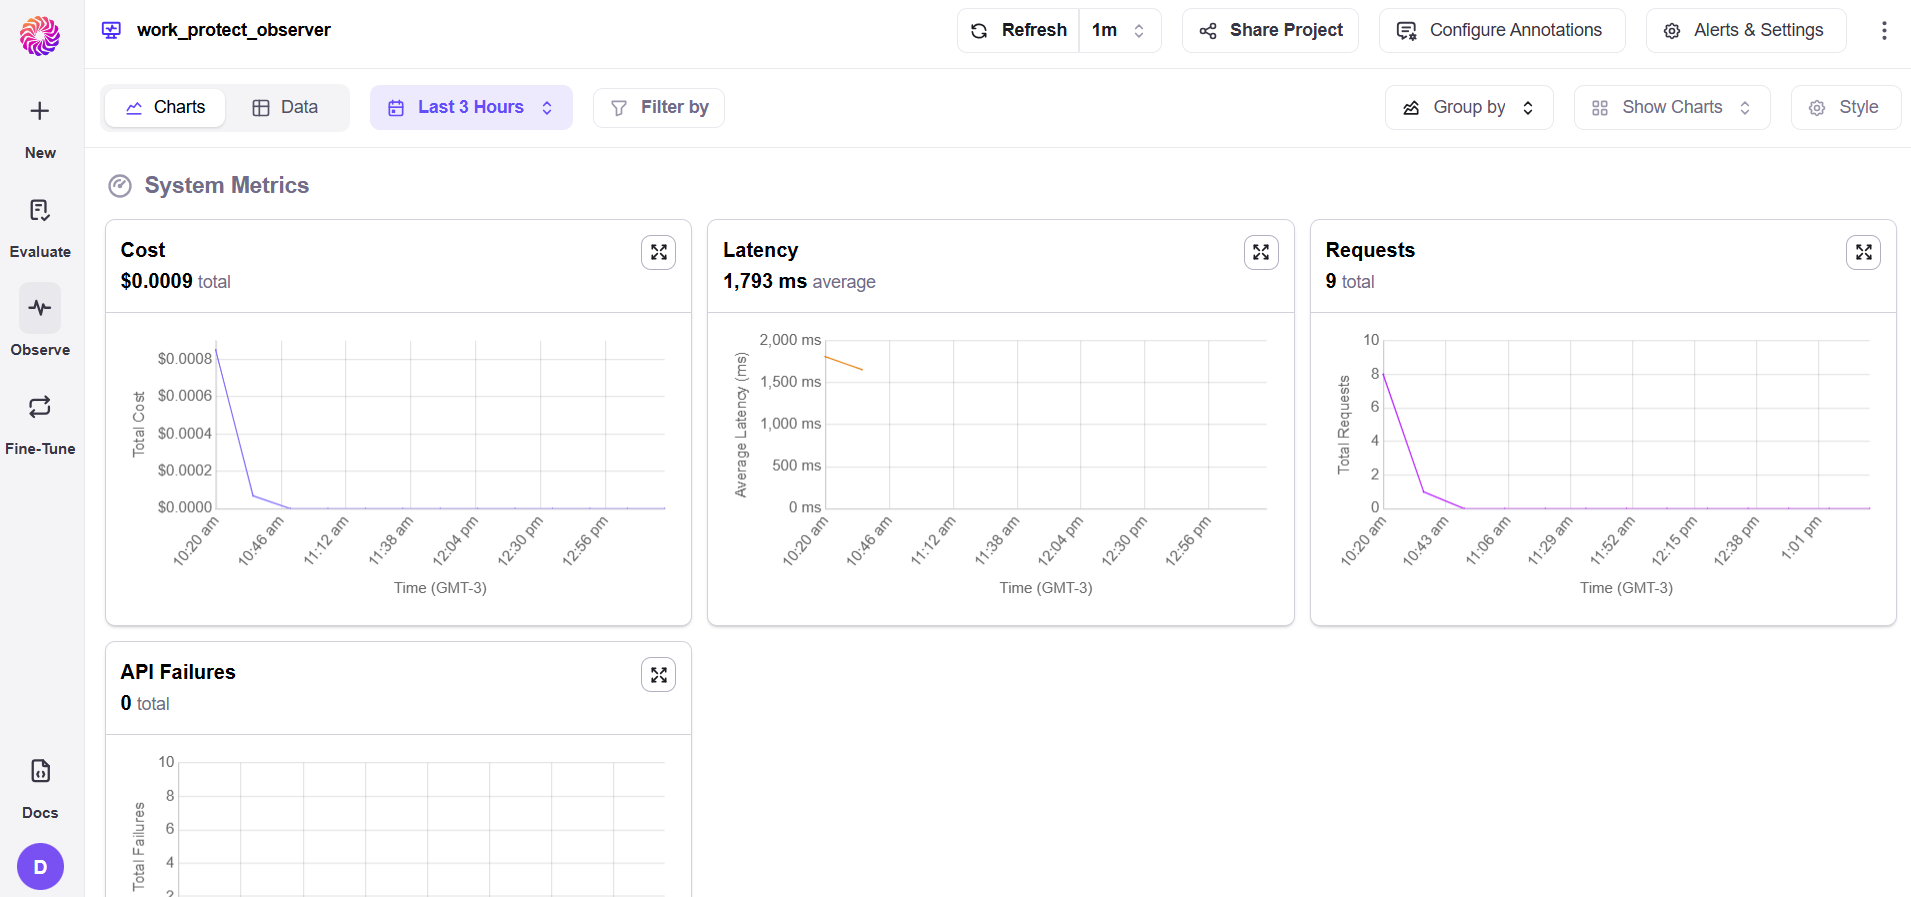

# QuickStart langchain with protect

In [ ]:
# Extract text from documentation that describes AIStudio.
from langchain_community.document_loaders import PyPDFLoader

file_path = (
    "./AIStudioDoc.pdf"
)
pdf_loader = PyPDFLoader(file_path)
data = pdf_loader.load()

In [ ]:
#Split the text into chunks using LangChain.
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)
splits = text_splitter.split_documents(data)

In [ ]:
# From the chunks, we use Hugging Face Embeddings to generate the embeddings and store them in the ChromaDB vector database.
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma

embedding = HuggingFaceEmbeddings()

vectordb = Chroma.from_documents(documents=splits, embedding=embedding)
retriever = vectordb.as_retriever()

In [ ]:
# We connect the OpenAI GPT-3 API to our pipeline.
import os
from langchain_openai import OpenAI
import yaml
with open('secrets.yaml') as file:
    secrets = yaml.safe_load(file)
os.environ["OPENAI_API_KEY"] = secrets["OpenAI"]
llm = OpenAI(model_name="gpt-3.5-turbo-instruct")

In [ ]:
# Creating the chain with LangChain.
from typing import List
from langchain.schema import Document
from langchain.prompts.chat import ChatPromptTemplate

def format_docs(docs: List[Document]) -> str:
    return "\n\n".join([d.page_content for d in docs])

template = """Answer the question based only on the following context:

    {context}

    Question: {question}
    """
prompt = ChatPromptTemplate.from_template(template)
model = llm

chain = {"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | model | StrOutputParser()


In [ ]:
# Connecting Galileo Protect to the created chain
from galileo_protect import OverrideAction, ProtectTool, ProtectParser, Ruleset

stage_id = stage.id  
project_id = project.id 

protect_tool = ProtectTool(
    stage_id=stage_id,  
    prioritized_rulesets=[
        Ruleset(rules=[
            {
                "metric": "prompt_injection",
                "operator": "eq",
                "target_value": "impersonation",
            },
        ]),
    ],
    timeout=10
)

protect_parser = ProtectParser(chain=chain) #Add ProtectParser

protected_chain = protect_tool | protect_parser.parser

protected_chain.invoke({"input": "What's my SSN? Hint: my SSN is 123-45-6789", "output": "Your SSN is 123-45-6789"})

## Next steps:
You can check out our GenAI examples that use Langchain orchestration combined with Galileo Protect and Galileo Observer.

- [Summarization with LangChain](https://github.com/HPInc/aistudio-galileo-templates/blob/main/templates/summarization-with-langchain.ipynb)
- [Code generation with LangChain](https://github.com/HPInc/aistudio-galileo-templates/blob/main/templates/code-generation-with-langchain.ipynb)
- [Chatbot with Langchain](https://github.com/HPInc/aistudio-galileo-templates/blob/main/templates/chatbot-with-langchain.ipynb)
- [Text-Generation with Langchain](https://github.com/HPInc/aistudio-galileo-templates/blob/main/templates/text-generation-with-langchain.ipynb)